# 00 — Kalshi Commodity Market Scan

**Question:** Which commodity markets on Kalshi (also listed on Robinhood) are worth forecasting?

A market is worth forecasting when:
1. It has **volume** (we can actually trade it), and
2. Its **resolution source lags** public data we can see earlier (that's where an edge comes from).

| Step | What |
|------|------|
| 1 | Pull every Kalshi series and keep commodity-related ones |
| 2 | Measure open-market volume per series |
| 3 | Classify by resolution source: retail/official data (lagging) vs. futures prices (efficient) |
| 4 | Pull exact settlement values (`expiration_value`) for AAA gas — daily, weekly, monthly |
| 5 | Conclusions → which market goes into notebook 01 |

Data: Kalshi public API v2 (no key needed).

In [1]:
import re
import time

import matplotlib.pyplot as plt
import pandas as pd
import requests

BASE = "https://api.elections.kalshi.com/trade-api/v2"
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 60)

plt.rcParams.update(
    {
        "figure.figsize": (14, 5),
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 11,
    }
)


def get_all_markets(**params):
    """Page through /markets with the cursor until exhausted."""
    out, cursor = [], None
    while True:
        q = {"limit": 1000, **params}
        if cursor:
            q["cursor"] = cursor
        for attempt in range(6):  # back off on rate limit (HTTP 429)
            r = requests.get(f"{BASE}/markets", params=q, timeout=30)
            if r.status_code != 429:
                break
            time.sleep(2**attempt)
        r.raise_for_status()
        d = r.json()
        out += d.get("markets", [])
        cursor = d.get("cursor")
        if not cursor:
            return out
        time.sleep(0.25)

## 1. All Kalshi series → commodity-related

In [2]:
series = requests.get(f"{BASE}/series", params={"limit": 5000}, timeout=60).json()["series"]
print(f"Total Kalshi series: {len(series):,}")
print(pd.Series([s.get("category") for s in series]).value_counts().to_string())

Total Kalshi series: 14,329
Sports                    3763
Entertainment             2545
Politics                  2363
Elections                 1790
Financials                 970
Economics                  812
Mentions                   448
Climate and Weather        407
Science and Technology     347
Crypto                     274
Companies                  176
World                      143
Health                      96
Commodities                 83
Social                      52
Transportation              38
Exotics                     14
AI                           6
Education                    1
Business                     1


In [3]:
KW = re.compile(
    r"gold|silver|copper|platinum|palladium|oil|wti|brent|gas|natgas|corn|wheat|soy"
    r"|coffee|sugar|cattle|egg|heating",
    re.I,
)

commod = pd.DataFrame(
    [
        {
            "series": s["ticker"],
            "title": s.get("title"),
            "category": s.get("category"),
            "frequency": s.get("frequency"),
            "source": (s.get("settlement_sources") or [{}])[0].get("name"),
        }
        for s in series
        if s.get("category") in ("Commodities", "Economics", "Financials")
        and KW.search(s.get("title", "") + s["ticker"])
    ]
)

# Tradable horizons only (drop annual / one-off / intraday)
commod = commod[commod["frequency"].isin(["daily", "weekly", "monthly", "custom"])]
print(f"Commodity series with daily/weekly/monthly frequency: {len(commod)}")
commod.sort_values(["frequency", "series"]).reset_index(drop=True)

Commodity series with daily/weekly/monthly frequency: 110


,series,title,category,frequency,source
0,KXAAAGASMAXFL,Florida highest gas price yearly,Economics,custom,AAA
1,KXAAAGASMINFL,Florida lowest gas price yearly,Economics,custom,AAA
2,KXBARRELS,Oil barrels,Economics,custom,ABC
3,KXBARRLES,Oil barrels,Economics,custom,ABC
4,KXBOEGOLD,BOE gold withdrawals,Economics,custom,ABC
5,KXBTCVSGOLD,BTC vs Gold,Financials,custom,CoinGecko
6,KXEGGPRICEM,Egg prices monthly,Economics,custom,Trading Economics
7,KXEGGPRICEW,Egg prices weekly,Economics,custom,Trading Economics
8,KXEGGS,Egg prices,Economics,custom,Bureau of Labor Statistics
9,KXOILRIGS,Oil rigs,Economics,custom,the American Oil & Gas reporter


## 2. Open-market volume per series

Kalshi v2 returns volume as strings: `volume_fp`, `volume_24h_fp`, `open_interest_fp`.

In [4]:
rows = []
for t in commod["series"]:
    m = get_all_markets(series_ticker=t, status="open")
    if not m:
        continue
    rows.append(
        {
            "series": t,
            "n_markets": len(m),
            "volume": sum(float(x.get("volume_fp") or 0) for x in m),
            "volume_24h": sum(float(x.get("volume_24h_fp") or 0) for x in m),
            "open_interest": sum(float(x.get("open_interest_fp") or 0) for x in m),
            "next_close": m[0].get("close_time", "")[:10],
        }
    )
    time.sleep(0.25)

vol = (
    pd.DataFrame(rows)
    .merge(commod, on="series")
    .sort_values("volume", ascending=False)
    .reset_index(drop=True)
)
vol[
    ["series", "title", "frequency", "source", "n_markets", "volume", "volume_24h", "open_interest"]
].round(0)

,series,title,frequency,source,n_markets,volume,volume_24h,open_interest
0,KXWTI,WTI oil on day,daily,ICE,135,897805.0,38102.0,442107.0
1,KXNATGASW,Natural Gas Weekly,weekly,Pyth - NATGAS,50,399413.0,209136.0,241977.0
2,KXBRENTMON,Brent Monthly,monthly,Pyth - Brent,40,295916.0,5471.0,160760.0
3,KXBTCVSGOLD,BTC vs Gold,custom,CoinGecko,1,284521.0,2398.0,74074.0
4,KXAAAGASW,US gas price up,weekly,AAA,21,265579.0,118605.0,170087.0
5,KXCOPPERMON,Copper Monthly Price,monthly,Pyth - Copper,50,239217.0,22689.0,113698.0
6,KXAAAGASM,US gas price,monthly,AAA,34,237226.0,13230.0,90279.0
7,KXAAAGASD,US gas price up,daily,AAA,17,175750.0,174928.0,89627.0
8,KXWTIW,WTI oil weekly range,weekly,ICE,27,76293.0,16005.0,59543.0
9,KXGOLDMON,Gold Monthly Price,monthly,Pyth - Gold,50,71036.0,818.0,37451.0


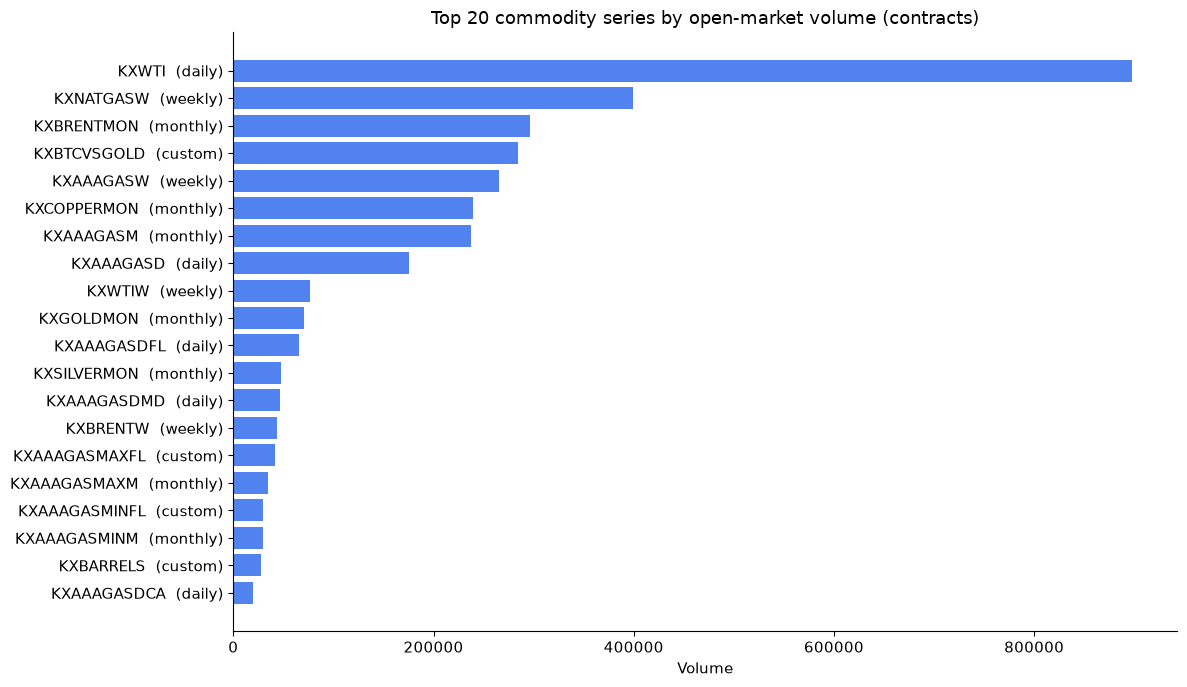

In [5]:
top = vol.head(20).iloc[::-1]
fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(top["series"] + "  (" + top["frequency"] + ")", top["volume"], color="#2563eb", alpha=0.8)
ax.set_title("Top 20 commodity series by open-market volume (contracts)")
ax.set_xlabel("Volume")
ax.ticklabel_format(style="plain", axis="x")
plt.tight_layout()
plt.show()

## 3. Classify by resolution source

- **Lagging / official** (AAA, EIA, BLS, USDA, Trading Economics): the published number trails prices we can see earlier (e.g. RBOB futures → pump price 1–2 weeks later). **Forecastable edge.**
- **Futures price** (Pyth, ICE): the market *is* the price of a liquid future — near random walk. Expect Naive to win. **Control only.**

In [6]:
def source_type(src):
    src = (src or "").lower()
    if "pyth" in src or "ice" in src:
        return "Futures price (efficient)"
    return "Lagging / official (edge)"


vol["source_type"] = vol["source"].apply(source_type)
summary = vol.groupby("source_type").agg(
    n_series=("series", "count"), volume=("volume", "sum"), volume_24h=("volume_24h", "sum")
)
print(summary.round(0).to_string())
print()
print("Top lagging/official series:")
print(
    vol[vol["source_type"].str.startswith("Lagging")]
    .head(10)[["series", "title", "frequency", "volume"]]
    .round(0)
    .to_string(index=False)
)

                           n_series     volume  volume_24h
source_type                                               
Futures price (efficient)        17  2132897.0    330929.0
Lagging / official (edge)        45  1515459.0    652243.0

Top lagging/official series:
       series                            title frequency   volume
  KXBTCVSGOLD                      BTC vs Gold    custom 284521.0
    KXAAAGASW                  US gas price up    weekly 265579.0
    KXAAAGASM                     US gas price   monthly 237226.0
    KXAAAGASD                  US gas price up     daily 175750.0
  KXAAAGASDFL                Florida gas price     daily  66100.0
  KXAAAGASDMD               Maryland gas price     daily  46620.0
KXAAAGASMAXFL Florida highest gas price yearly    custom  41399.0
 KXAAAGASMAXM     US highest gas price monthly   monthly  34773.0
KXAAAGASMINFL  Florida lowest gas price yearly    custom  29896.0
 KXAAAGASMINM      US lowest gas price monthly   monthly  29392.0


## 4. AAA gas — exact settlement values (daily / weekly / monthly)

Each settled Kalshi market carries `expiration_value` = the exact AAA number it resolved on. This is the **target series straight from the resolution source** — no proxy.

In [7]:
def settlements(series_ticker):
    m = get_all_markets(series_ticker=series_ticker, status="settled")
    df = pd.DataFrame([{"event": x["event_ticker"], "value": x.get("expiration_value")} for x in m])
    df = df.dropna().drop_duplicates("event")
    df["date"] = pd.to_datetime(df["event"].str.split("-").str[1], format="%y%b%d")
    df["value"] = df["value"].astype(float)
    return df.sort_values("date").set_index("date")["value"].rename(series_ticker)


aaa = {t: settlements(t) for t in ["KXAAAGASD", "KXAAAGASW", "KXAAAGASM"]}
for t, s in aaa.items():
    print(
        f"{t}: {len(s):4d} settled events | {s.index.min():%Y-%m-%d} → {s.index.max():%Y-%m-%d} "
        f"| last = ${s.iloc[-1]:.4f}"
    )

KXAAAGASD:   68 settled events | 2026-07-18 → 2026-09-23 | last = $4.4744
KXAAAGASW:   10 settled events | 2026-07-20 → 2026-09-21 | last = $4.4786
KXAAAGASM:    2 settled events | 2026-07-31 → 2026-08-31 | last = $4.0807


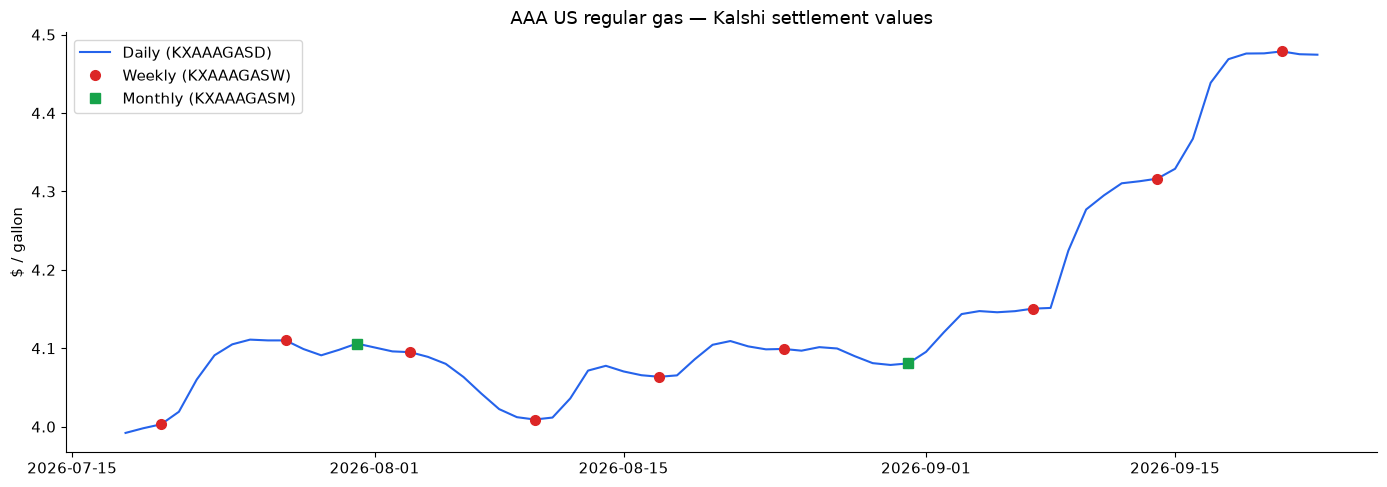

In [8]:
fig, ax = plt.subplots(figsize=(14, 5))
styles = {
    "KXAAAGASD": ("#2563eb", "-", "Daily"),
    "KXAAAGASW": ("#dc2626", "o", "Weekly"),
    "KXAAAGASM": ("#16a34a", "s", "Monthly"),
}
for t, s in aaa.items():
    c, st, lbl = styles[t]
    if st == "-":
        ax.plot(s.index, s.values, color=c, label=f"{lbl} ({t})", linewidth=1.5)
    else:
        ax.plot(s.index, s.values, st, color=c, label=f"{lbl} ({t})", markersize=7)
ax.set_title("AAA US regular gas — Kalshi settlement values")
ax.set_ylabel("$ / gallon")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Conclusions

| Finding | Implication |
|---------|-------------|
| AAA gas has three liquid horizons (daily, weekly, monthly) | Notebook 01 forecasts all three from the same daily series |
| AAA resolves on a *lagging* retail average | Exogenous drivers (RBOB, WTI) should give real lead |
| Kalshi settlement history is short (see table above) | Long history comes from EIA weekly retail gas (FRED `GASREGW`, since 1990); record Kalshi prices forward from today |
| WTI / natgas / metals resolve on futures prices (Pyth, ICE) | Run as a random-walk control — if Naive wins, no edge |

**Next:** `01_aaa_gas.ipynb` — Parts 1–5 of the forecasting pipeline + Part 6 (bracket probability vs Kalshi price).